In [1]:
import pandas as pd

In [2]:
d=pd.read_csv("Salary_Data.csv")
d

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [3]:
#d.drop(["Education Level","Job Title"],axis="columns")

In [4]:
d.columns[d.isnull().any()]

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [5]:
d=d.drop(["Education Level"],axis=1)

In [6]:
d

,Age,Gender,Job Title,Years of Experience,Salary
0,32.0,Male,Software Engineer,5.0,90000.0
1,28.0,Female,Data Analyst,3.0,65000.0
2,45.0,Male,Senior Manager,15.0,150000.0
3,36.0,Female,Sales Associate,7.0,60000.0
4,52.0,Male,Director,20.0,200000.0
...,...,...,...,...,...
6699,49.0,Female,Director of Marketing,20.0,200000.0
6700,32.0,Male,Sales Associate,3.0,50000.0
6701,30.0,Female,Financial Manager,4.0,55000.0
6702,46.0,Male,Marketing Manager,14.0,140000.0


In [7]:
d["Gender"].value_counts()

Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64

In [8]:
e=pd.get_dummies(d["Gender"])

In [9]:
d=pd.concat([d,e],axis=1)
d

,Age,Gender,Job Title,Years of Experience,Salary,Female,Male,Other
0,32.0,Male,Software Engineer,5.0,90000.0,False,True,False
1,28.0,Female,Data Analyst,3.0,65000.0,True,False,False
2,45.0,Male,Senior Manager,15.0,150000.0,False,True,False
3,36.0,Female,Sales Associate,7.0,60000.0,True,False,False
4,52.0,Male,Director,20.0,200000.0,False,True,False
...,...,...,...,...,...,...,...,...
6699,49.0,Female,Director of Marketing,20.0,200000.0,True,False,False
6700,32.0,Male,Sales Associate,3.0,50000.0,False,True,False
6701,30.0,Female,Financial Manager,4.0,55000.0,True,False,False
6702,46.0,Male,Marketing Manager,14.0,140000.0,False,True,False


In [10]:
d=d.drop(["Gender"],axis=1)

In [11]:
d

,Age,Job Title,Years of Experience,Salary,Female,Male,Other
0,32.0,Software Engineer,5.0,90000.0,False,True,False
1,28.0,Data Analyst,3.0,65000.0,True,False,False
2,45.0,Senior Manager,15.0,150000.0,False,True,False
3,36.0,Sales Associate,7.0,60000.0,True,False,False
4,52.0,Director,20.0,200000.0,False,True,False
...,...,...,...,...,...,...,...
6699,49.0,Director of Marketing,20.0,200000.0,True,False,False
6700,32.0,Sales Associate,3.0,50000.0,False,True,False
6701,30.0,Financial Manager,4.0,55000.0,True,False,False
6702,46.0,Marketing Manager,14.0,140000.0,False,True,False


In [12]:
d.columns[d.isnull().any()]

Index(['Age', 'Job Title', 'Years of Experience', 'Salary'], dtype='object')

In [13]:
d['Years of Experience']=d['Years of Experience'].fillna(d['Years of Experience'].mean())

In [14]:
d['Salary']=d['Salary'].fillna(d['Salary'].mean())

In [15]:
#pip install scikit-learn

In [16]:
from sklearn.model_selection import  train_test_split

In [17]:
x=d[["Years of Experience"]]
y=d["Salary"]
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)
x_test

,Years of Experience
2794,19.0
2233,8.0
5559,3.0
6355,2.0
263,3.0
...,...
2820,32.0
3165,8.0
5947,0.0
6429,3.0


In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
from sklearn.metrics import r2_score

In [20]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pre=lr.predict(x_test)
y_pre

array([192634.474479  , 114754.49957938,  79354.51098865, ...,
        58114.51783421,  79354.51098865,  72274.5132705 ], shape=(2012,))

In [22]:
lr.coef_

array([7079.99771815])

In [23]:
lr.intercept_

np.float64(58114.51783420501)

In [24]:
r2_score(y_test,y_pre)

0.6434486563267621

In [25]:
import numpy as np
a=np.array(4.7).reshape(-1,1)
b=lr.predict(a)
b

C:\Users\gavas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([91390.5071095])

In [26]:
import matplotlib.pyplot as plt

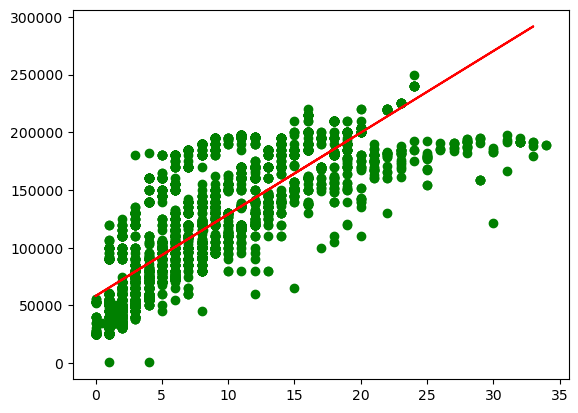

In [30]:
plt.scatter(x_train,y_train,color="green")
plt.plot(x_test,y_pre,color="red")
plt.show()